a) The differential equation above describes the decrease of c in the surrounding fluid, which corresponds to the total uptake of all cells. Show (somehow) that the maximal uptake rate per cell is Kmax as c goes to infinity? 

According to the given differential equation, n corresponds to the total cell density. Because the question asks specifically about the maximal uptake rate per cell, n will be ignored in this answer. Similarly, the equation solves for the decrease in c, while we explain maximal uptake rate, the negative will also be ignored.

This leaves us with the uptake per cell as (Kmax x c)/(kn + c). Examining the limit as c -> ∞, kn becomes negligible, as any addition of kn in the denominator as c -> ∞ will not change much. Therefore, one can look more simply at the limit c -> ∞ as (Kmax x c)/(c). The c variables cancel out and we are left with the limit as c -> ∞ to be Kmax. Using this limiting argument and reasoning, the maximal uptake rate per cell is Kmax as c -> ∞. This makes sense biologically, as the nutrient concentration becomes infinite, the uptake is limited by the maximum rate possible per cell. 


b) Confirm (mathematically) that c = 0 is an equilibrium, and that it is stable (1p)

Kmax, n, and kn are all presumed to be positive non-zero values in a physiologically relevent situation. Therefore, when one sets the rate of nutrient concentration to zero, the only possible solution is when c = 0 (making the numerator zero). This equation only looks at nutrient depletion and each term continuously leads to depletion (a non-zero depletion rate) unless nutrients are not present. 

Since this is a one-dimensional system, one can asses stability by taking the derivitive of the rate equation and plugging in the equillbrium value of interest. If this derivitie is less than zero, the equillibrium is stable and any perterbations around it will "push" the rate back to the equillibrium. To determine whether c = 0 is stable, the work is shown below. The derivitive is taken with a combination of the product and chain rule and c* = 0 is plugged in. As seen, f'(c*) < 0 (with the assumption above that n, Kmax, and kn are always non-zero positive values). This also makes sense biologically, if nutrients are present and rate of uptake is positive, the nutrients will always deplete towards 0.


c) Write an R script that solves the differential equation above and plots the result as a function of time). All model parameters should be positive, but otherwise arbitrary. (1p)

[1] "time" "1"   


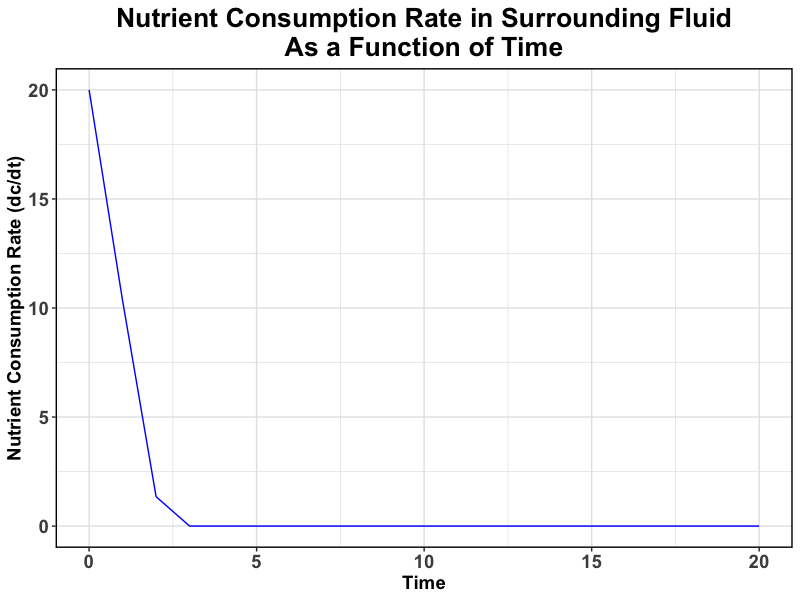

In [17]:
#install.packages("deSolve")  # installing necessary package for ode functionality 
#install.packages("ggplot2")
#library(deSolve)
#library(ggplot2)

Kmax <-  0.2     # maximal uptake rate for a single cell 
kn <-  0.5  # half saturation constant
n <-  50   # denisty of cells per unit volume

parms <- list(Kmax = Kmax, kn = kn, n = n) # list of the above parameters to feed into the ode function

kinetics <- function(t, c, parms) {   # nutrient uptake function (takes in time, nutrient [], and constants)
  dcdt <- -((parms$Kmax * c)/(parms$kn + c))*parms$n  # parms$____ accesses the necessary constant from the parms list
  return(list(dcdt))  # returns the rate of nutrient [] change as a list
}

times <- seq(0, 20, by = 1)  # sequence of times starting from 0-20 by 1 increment (arbitratily setting unit to hours)

init_c <- 20  # initial concentration of nutrient to begin with 

output <- ode( y = init_c, func = kinetics, times = times, parms = parms)  # calling on the ode function from deSolver to save the solutions of the diff rate equation for each time point

df <- as.data.frame(output) # converting ode output from matrix to data frame for ggplot2

print(colnames(df)) # inspecting colnames to feed into ggplot2 aes parameter

colnames(df)[2] <- "dcdt" # changing ode output col name more meaningfully

plot <- ggplot(df, aes(x = time, y = dcdt)) +   # using ggplot to plot the elements "time" and "dcdt" from the dataframe generated by ode solver
  geom_line(color = "blue") + # telling ggplot the graph type
  labs(   # adding labels
    title = ("Nutrient Consumption Rate in Surrounding Fluid\nAs a Function of Time"),
    y = ("Nutrient Consumption Rate (dc/dt)"),
    x = ("Time")
  )+
  theme( # adjusting aesthetics 
    panel.background = element_rect(fill = "white"),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_line(color = "grey90"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, face = "bold"), 
    axis.title.y = element_text(size = 14, face = "bold"), 
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold")) 



print(plot)


d) Write the new equation for the nutrient dynamics! (1p)

dc/dt = (I - µc) + (-(Kmax*c)/(kn + c) * n)

Nurients are added via variable I, taken away by the outflow µc, and also taken away by cellular uptake (original part of the equation).

e) Adjust the R-script according to the new model

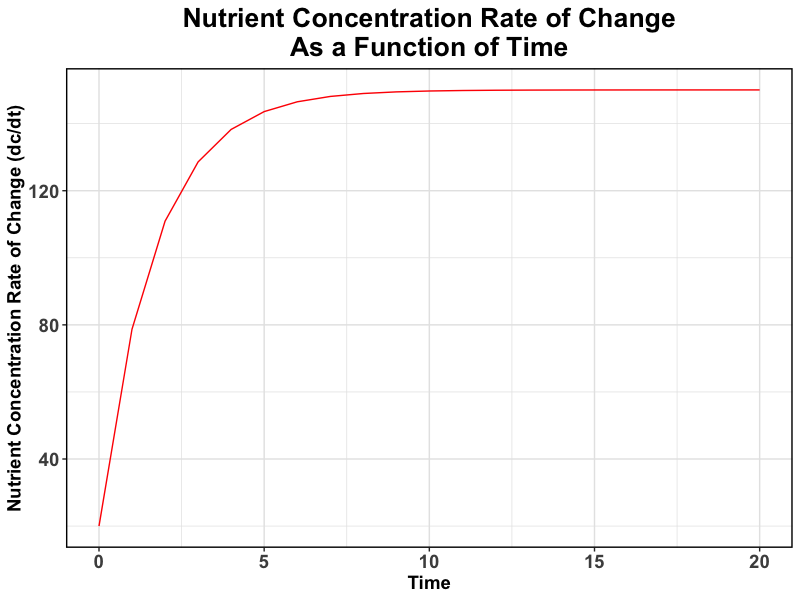

In [21]:
#install.packages("deSolve")  # installing necessary package for ode functionality 
#install.packages("ggplot2")
#library(deSolve)
#library(ggplot2)

Kmax <-  0.2     # maximal uptake rate for a single cell 
kn <-  0.5  # half saturation constant
n <-  50   # denisty of cells per unit volume

I <-  100    # constant inflow
mu <- 0.6   # outflow 

parms <- list(Kmax = Kmax, kn = kn, n = n, I = I, muc = mu) # list of the above parameters to feed into the ode function

kinetics_chemostat <- function(t, c, parms) {   # nutrient uptake function (takes in time, nutrient [], and constants)
  dcdt <- (parms$I - parms$mu*c + (-((parms$Kmax * c)/(parms$kn + c))*parms$n))  # parms$____ accesses the necessary constant from the parms list
  return(list(dcdt))  # returns the rate of nutrient [] change as a list
}

times <- seq(0, 20, by = 1)  # sequence of times starting from 0-20 by 1 increment 

init_c <- 20  # initial concentration of nutrient to begin with 

output <- ode( y = init_c, func = kinetics_chemostat, times = times, parms = parms)  # calling on the ode function from deSolver to save the solutions of the diff rate equation for each time point

df <- as.data.frame(output) # converting ode output from matrix to data frame for ggplot2

colnames(df) # inspecting colnames to feed into ggplot2 aes parameter

colnames(df)[2] <- "dcdt" # changing ode output col name more meaningfully

plot <- ggplot(df, aes(x = time, y = dcdt)) +   # using ggplot to plot the elements "time" and "dcdt" from the dataframe generated by ode solver
  geom_line(color = "red") + # telling ggplot the graph type
  labs(   # adding labels
    title = ("Nutrient Concentration Rate of Change\nAs a Function of Time"),
    y = ("Nutrient Concentration Rate of Change (dc/dt)"),
    x = ("Time")
  )+
  theme( # adjusting aesthetics 
    panel.background = element_rect(fill = "white"),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_line(color = "grey90"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, face = "bold"), 
    axis.title.y = element_text(size = 14, face = "bold"), 
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold")) 



print(plot)


f) Is there a new equilibrium? Is it stable? (Use either simulations in R or your own
calculations for this) (1p)

To check for the new equilbrium I set the new equation equal to zero. One can see that when I = µc + (Kmax * c * n)/(Kn +c) there is a new equillibrium (these will sum to zero in the equation). To find the stability of this equilibrium, I took the derivitive of the new equation. As shown in the work below, this came out to be f'(c) = -µ - (Kmax * n * Kn)/(kn + c)^2. To find the numeric equillibrium (to then plug into the derivitve and check whether it is negative) R was used. No matter what parameters are used, when the new equilibrium is plugged into the derivitive, the solution is negative, making this equilibrium stable. 

One can also see this when looking at the derivitive f'(c) = -µ - (Kmax * n * Kn)/(kn + c)^2. Based on the biological restraints for the constants and c, f'(c*) will always be negative. 

In [ ]:
# solving for the c* equilibrium for an arbitrary set of parameters to double check for stability

Kmax <-  0.2     # maximal uptake rate for a single cell 
kn <-  0.5  # half saturation constant
n <-  50   # denisty of cells per unit volume

I <-  100    # constant inflow
mu <- 0.6   # outflow 

kinetics_chemostat <- function(c) {
  I - mu*c + (-(Kmax*c)/(kn + c) * n) # nutrient uptake function (takes in time, nutrient [], and constants)

}

c_equil <- uniroot(kinetics_chemostat, interval = c(0, 1000))  # using uniroot to find the "root" of the original chemostat kinetics equation (where it == 0)

c_equil <- c_equil$root  # saving the root numeric portion of uniroots output 

kinetics_chemostat_deriv <- function(c) {   # defining a new function with the derivitive of our originial chemostat kinetics equation (solved for on paper)
  -mu - ((Kmax*n*kn)/(kn + c)^2)
}


print(kinetics_chemostat_deriv(c = c_equil))  # solving and printing the result of f'(c*) --> one can see this is negative even when parameters are changed within limits


[1] -0.6002206
